In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Ground Data EDA

In [21]:
from typing import Union, List
from datetime import datetime

def plot_ghi_yearly_distribution(data_measurement: pd.DataFrame, data_estimates: Union[pd.DataFrame, List[pd.DataFrame]] = None, estimate_labels: Union[str, List[str]] = None):
    """
    Create separate figures showing GHI distribution by year and daily statistics for each location.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame containing 'datetime' and 'ghi' columns
        
    Returns:
    --------
    fig, axes : tuple
        Figure and axes objects for further customization if needed
    """
    # Prepare date-related columns
    data_measurement = data_measurement.copy()
    data_measurement['Date'] = pd.to_datetime(data_measurement['datetime'])
    data_measurement['Year'] = data_measurement['Date'].dt.year
    data_measurement['DayOfYear'] = data_measurement['Date'].dt.dayofyear


    data_estimates_copy = []
    if data_estimates is not None:
        if isinstance(data_estimates, pd.DataFrame):
            data_estimates = [data_estimates]

        for data_estimate in data_estimates:
            data_estimate_copy = data_estimate.copy()
            data_estimate_copy['Date'] = pd.to_datetime(data_estimate_copy['datetime'])
            data_estimate_copy['Year'] = data_estimate_copy['Date'].dt.year
            data_estimate_copy['DayOfYear'] = data_estimate_copy['Date'].dt.dayofyear
            data_estimates_copy.append(data_estimate_copy)
    
    locations = data_measurement['location'].unique()
    all_figs = []
    all_axes = []

    for location in locations:
        location_data = data_measurement[data_measurement['location'] == location]
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Left plot: GHI for all years overlayed
        years = location_data['Year'].unique()
        color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
        colors = [color_list[i % len(color_list)] for i in range(len(years))]

        for j, year in enumerate(years):
            year_data = location_data[location_data['Year'] == year]
            axes[0].plot(year_data['DayOfYear'], year_data['ghi'], 
                        color=colors[j], alpha=0.7, label=str(year))

        axes[0].set_xlabel('Day of Year')
        axes[0].set_ylabel('GHI (W/m²)')
        axes[0].set_title(f'Daily GHI Values in {location.capitalize()} by Year')
        axes[0].legend(loc='best')
        axes[0].grid(True, alpha=0.3)

        # Right plot: Daily mean and std across years
        daily_stats = location_data.groupby(['DayOfYear'])['ghi'].agg(['mean', 'std']).reset_index()


        axes[1].plot(daily_stats['DayOfYear'], daily_stats['mean'],
                    'r--', label='Mean GHI')
        axes[1].fill_between(
            daily_stats['DayOfYear'], 
            daily_stats['mean'] - daily_stats['std'], 
            daily_stats['mean'] + daily_stats['std'], 
            color='blue', alpha=0.2, label='± 1 Std Dev'
        )

        if len(data_estimates_copy) > 0:
            for estimate_nbr in range(len(data_estimates_copy)):
                data_estimate = data_estimates_copy[estimate_nbr]
                location_estimates = data_estimate[data_estimate['location'] == location]
                daily_stats_estimates = location_estimates.groupby(['DayOfYear'])['ghi'].agg(['mean', 'std']).reset_index()

                axes[1].plot(daily_stats_estimates['DayOfYear'], daily_stats_estimates['mean'], label=estimate_labels[estimate_nbr])

        axes[1].set_xlabel('Day of Year')
        axes[1].set_ylabel('GHI (W/m²)')
        axes[1].set_title(f'Mean Daily GHI with Standard Deviation in {location.capitalize()}')
        axes[1].legend(loc='best')
        axes[1].grid(True, alpha=0.3)


        plt.tight_layout()
        all_figs.append(fig)
        all_axes.append(axes)
    
    return all_figs, all_axes, 

In [3]:
measurement_folder = Path('Data/irradiation_measurements')
cbe_measurements = measurement_folder / 'CBE_Data'
mak_measurements = measurement_folder / 'MAK_physics_dept'
ministry_measurements = measurement_folder / 'ministry_energy_ug'

In [4]:
estimate_folder = Path('Data/irradiation_estimates')
cbe_estimates = estimate_folder / 'CBE_Data'
ministry_estimates = estimate_folder / 'ministry_energy_ug'

In [19]:
location = 'soroti'
soroti = pd.read_csv(ministry_measurements / f'{location}.csv')
soroti.head()

,datetime,ghi,location,latitude,longitude
0,2020-02-01,2550.0,soroti,1.7153,33.6186
1,2020-02-02,6100.0,soroti,1.7153,33.6186
2,2020-02-03,4690.0,soroti,1.7153,33.6186
3,2020-02-04,6690.0,soroti,1.7153,33.6186
4,2020-02-05,6030.0,soroti,1.7153,33.6186


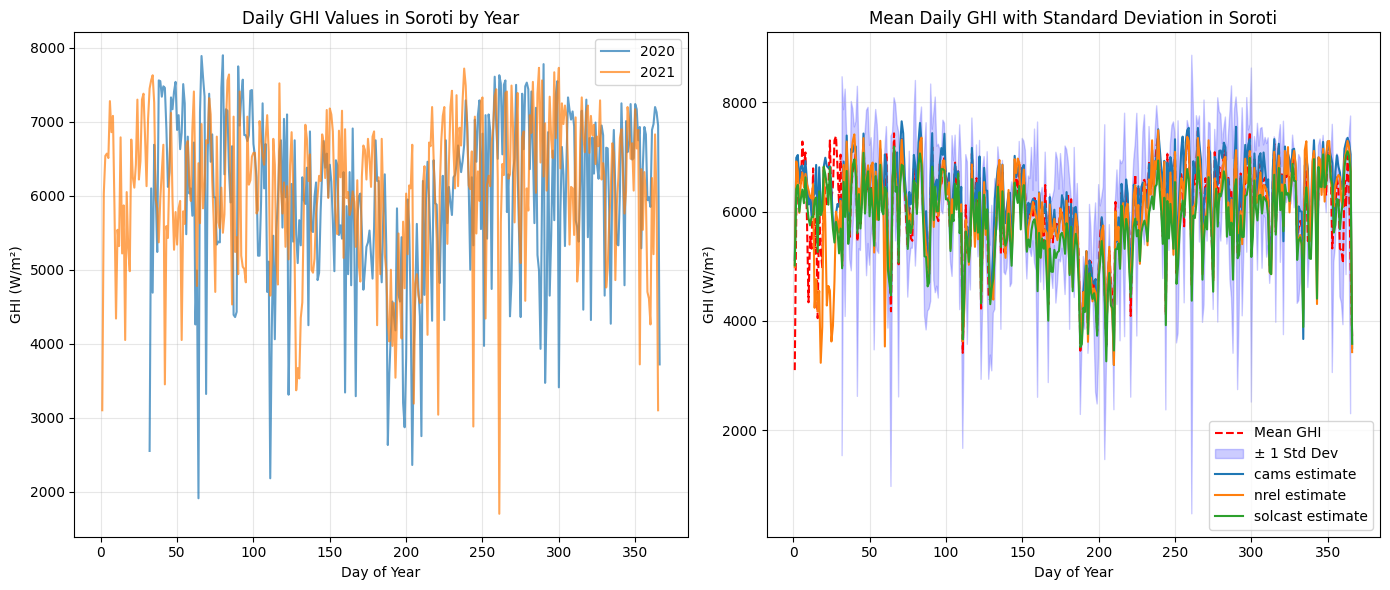

In [25]:
location = 'soroti'
soroti = pd.read_csv(ministry_measurements / f'{location}.csv')
soroti_cams = pd.read_csv(ministry_estimates / f'{location}_cams.csv')
soroti_nrel = pd.read_csv(ministry_estimates / f'{location}_nrel.csv')
soroti_solcast = pd.read_csv(ministry_estimates / f'{location}_solcast.csv')

fig, axes = plot_ghi_yearly_distribution(soroti, [soroti_cams, soroti_nrel, soroti_solcast], ['cams estimate', 'nrel estimate', 'solcast estimate'])
plt.show()

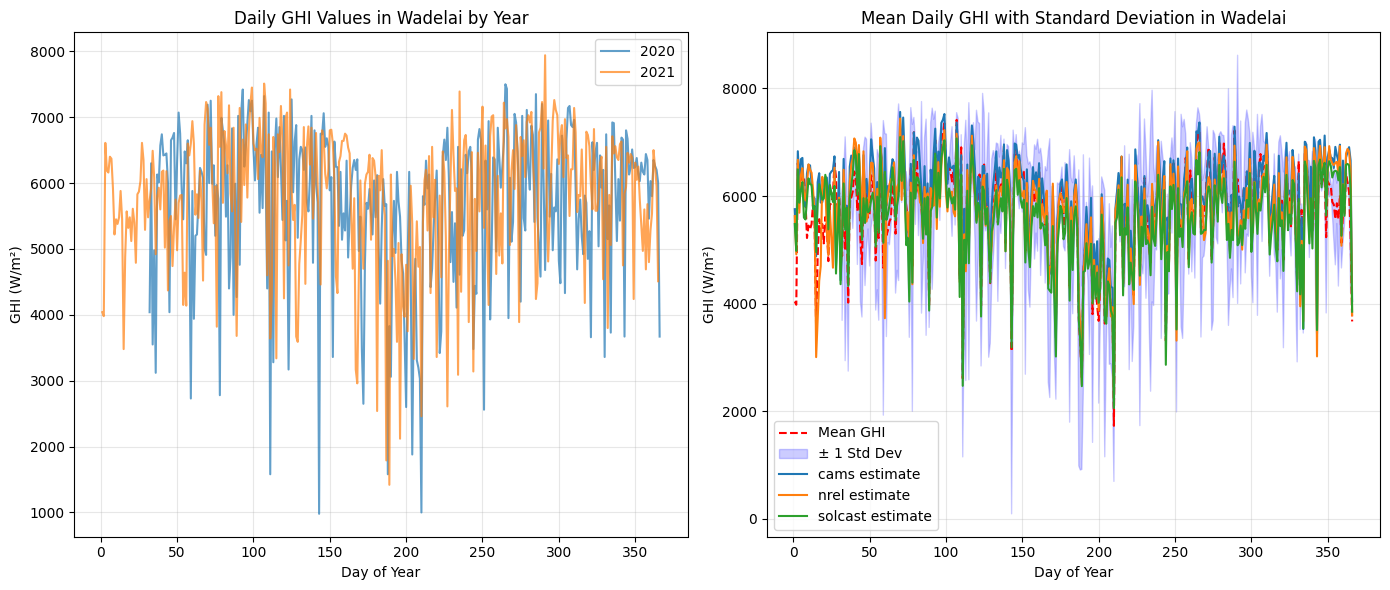

In [24]:
location = "wadelai"
wadelai = pd.read_csv(ministry_measurements / f'{location}.csv')

wadelai_cams = pd.read_csv(ministry_estimates / f'{location}_cams.csv')
wadelai_nrel = pd.read_csv(ministry_estimates / f'{location}_nrel.csv')
wadelai_solcast = pd.read_csv(ministry_estimates / f'{location}_solcast.csv')

fig, axes = plot_ghi_yearly_distribution(wadelai, [wadelai_cams, wadelai_nrel, wadelai_solcast], ['cams estimate', 'nrel estimate', 'solcast estimate'])
plt.show()

In [7]:
list(cbe_measurements.glob('*.csv'))

[PosixPath('Data/irradiation_measurements/CBE_Data/egypt.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/ghana.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/somalia.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/kenya.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/nigeria.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/madagascar.csv')]

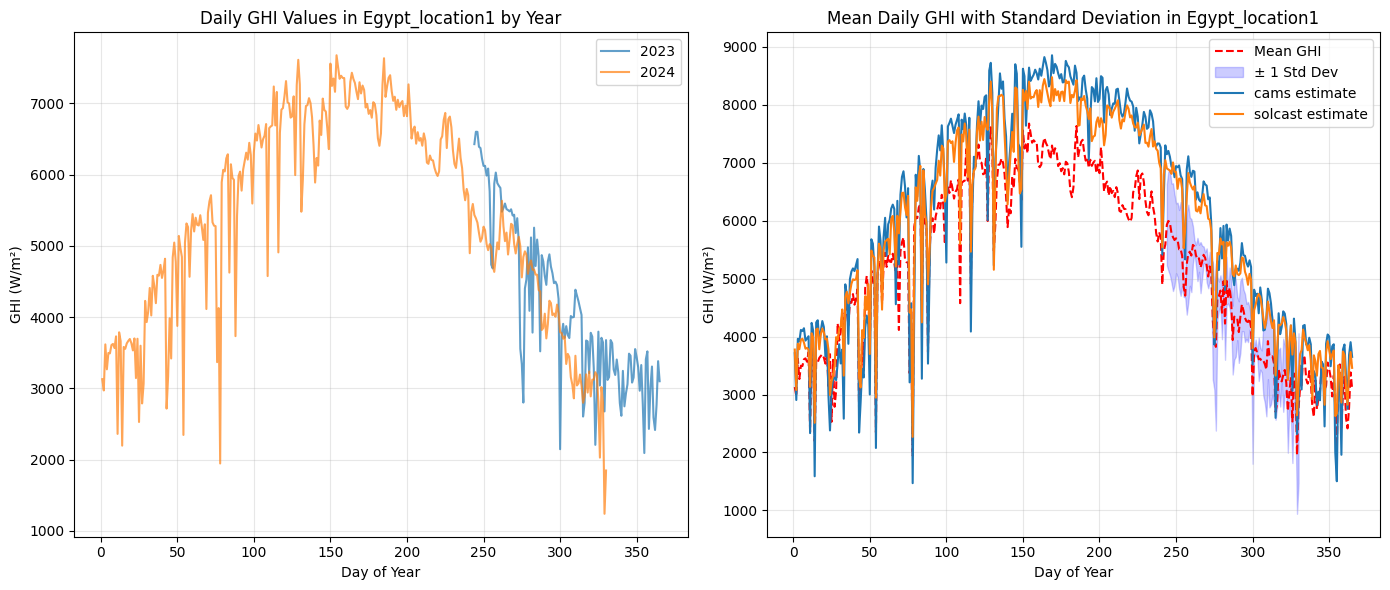

In [26]:
location = 'egypt'
egypt = pd.read_csv(cbe_measurements / f'{location}.csv')
egypt_cams = pd.read_csv(cbe_estimates / f'{location}_cams.csv')
egypt_solcast = pd.read_csv(cbe_estimates / f'{location}_solcast.csv')
fig, axes = plot_ghi_yearly_distribution(egypt, [egypt_cams, egypt_solcast], ['cams estimate', 'solcast estimate'])
plt.show()

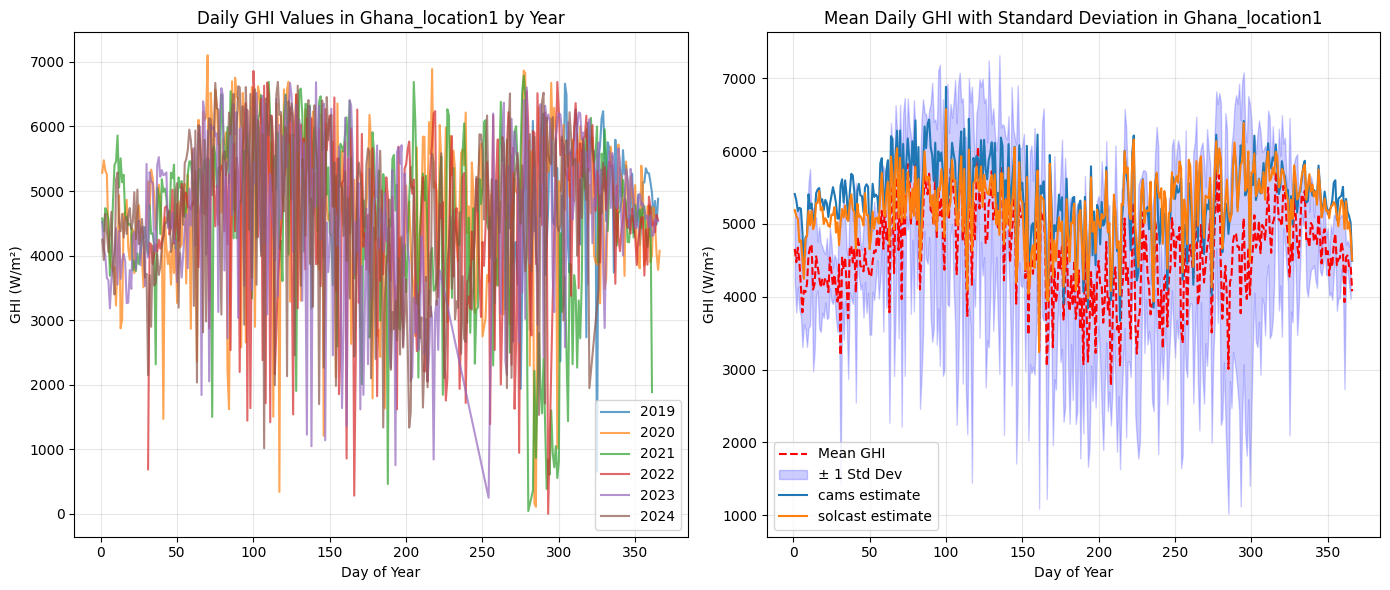

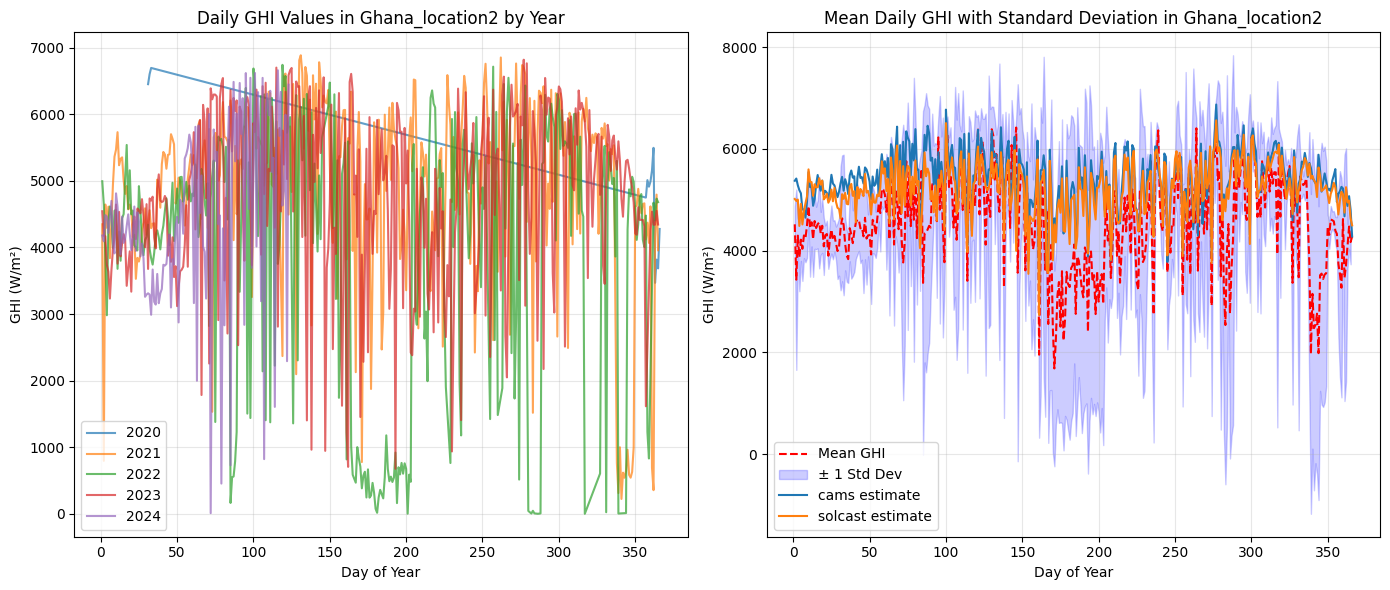

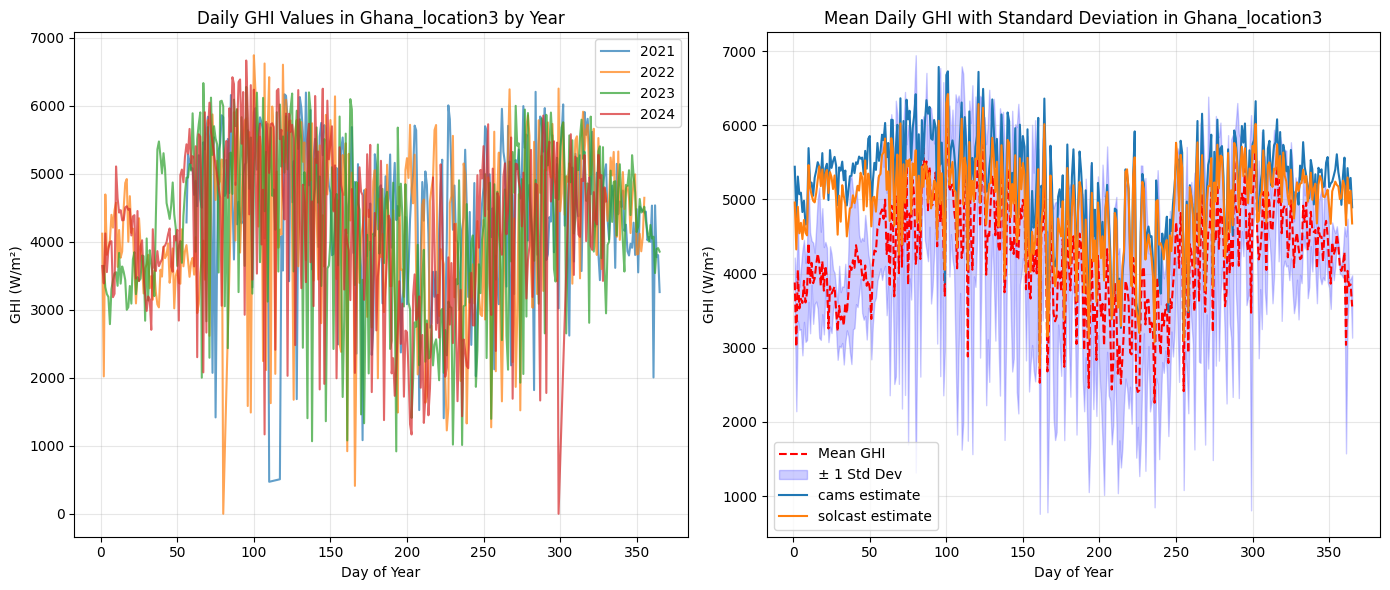

In [27]:
location = 'ghana'
ghana_measurement = pd.read_csv(cbe_measurements / f'{location}.csv')
ghana_cams = pd.read_csv(cbe_estimates / f'{location}_cams.csv')
ghana_solcast = pd.read_csv(cbe_estimates / f'{location}_solcast.csv')
fig, axes = plot_ghi_yearly_distribution(ghana_measurement, [ghana_cams, ghana_solcast], ['cams estimate', 'solcast estimate'])
plt.show()

# fig_estimates, axes_estimates = plot_ghi_yearly_distribution(ghana_estimates)
# plt.show()


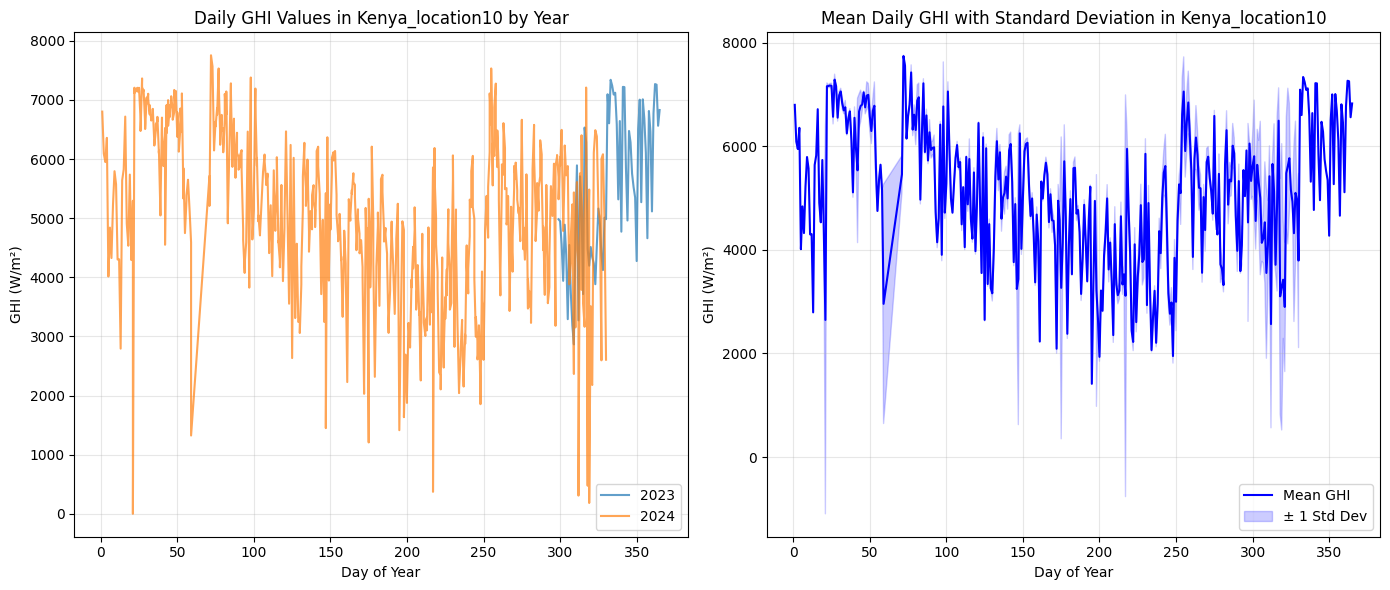

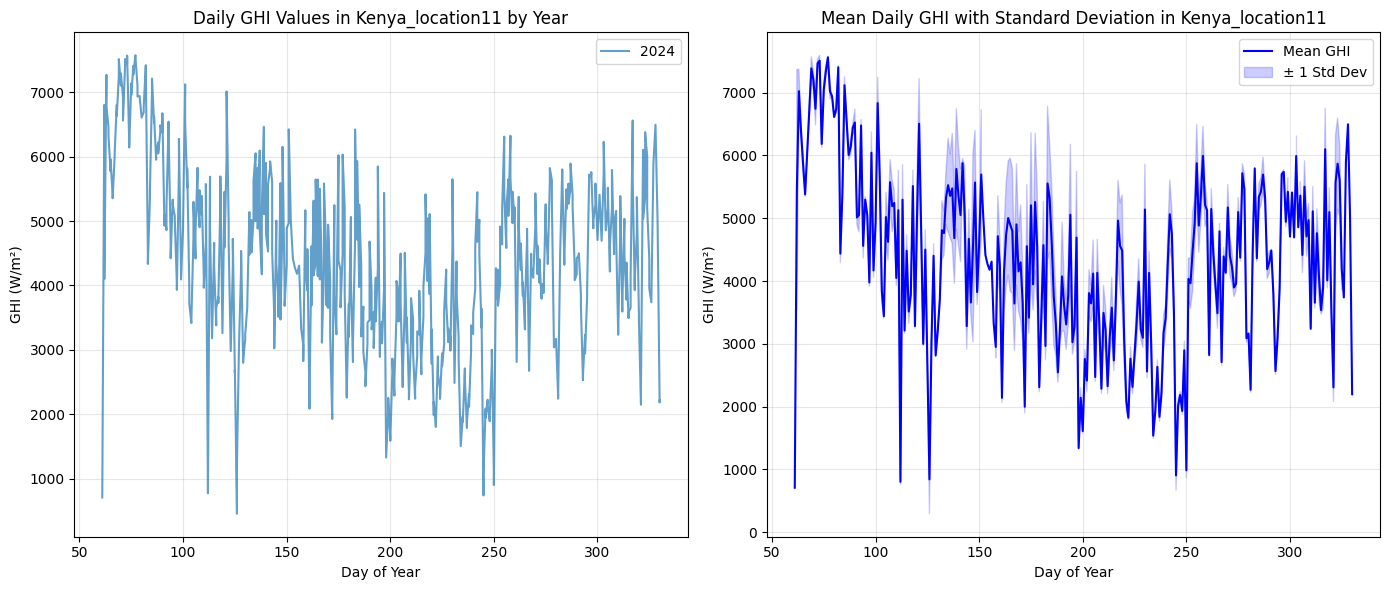

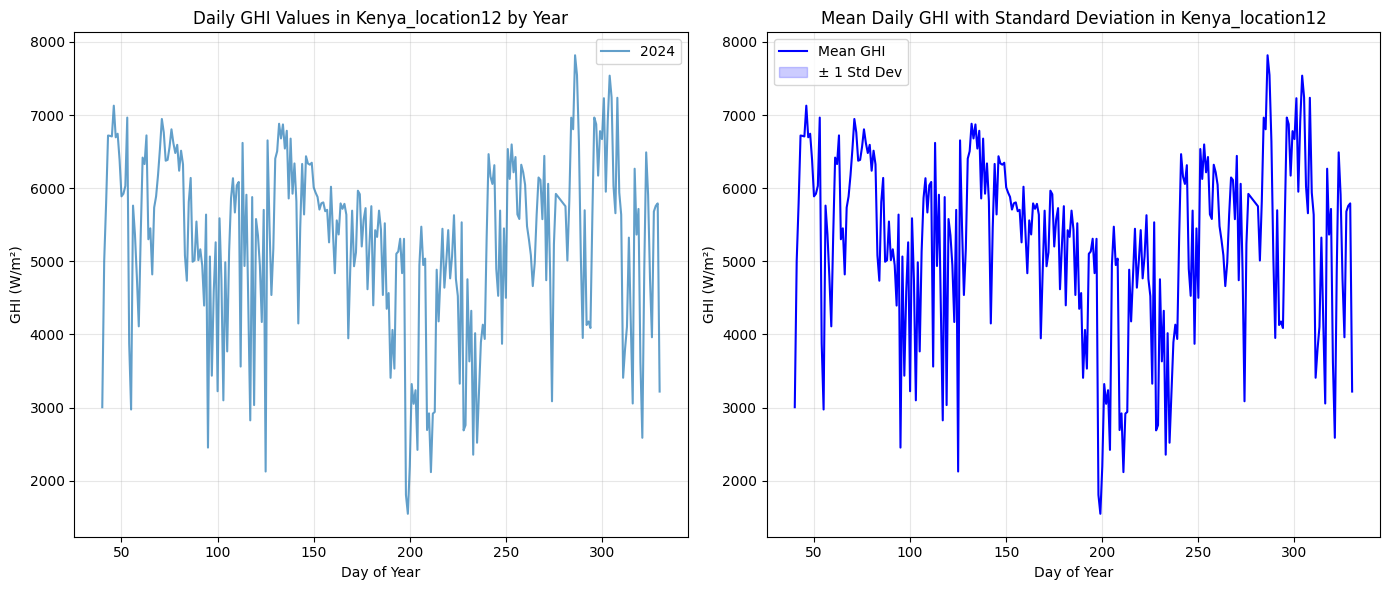

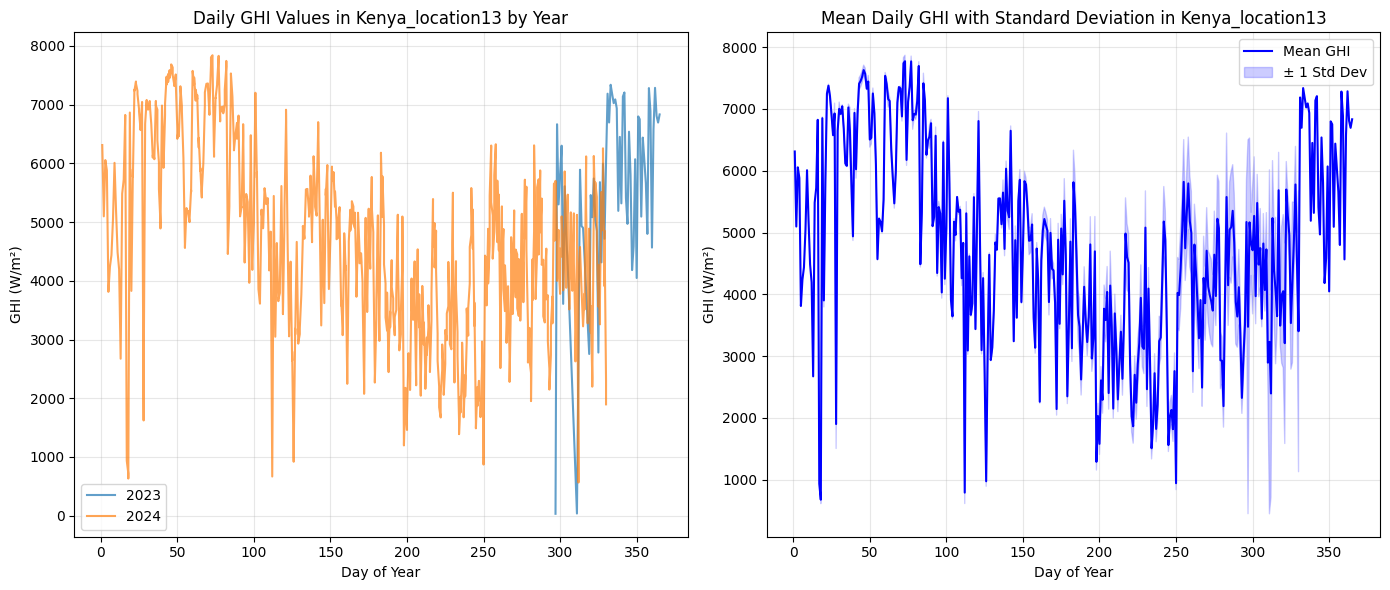

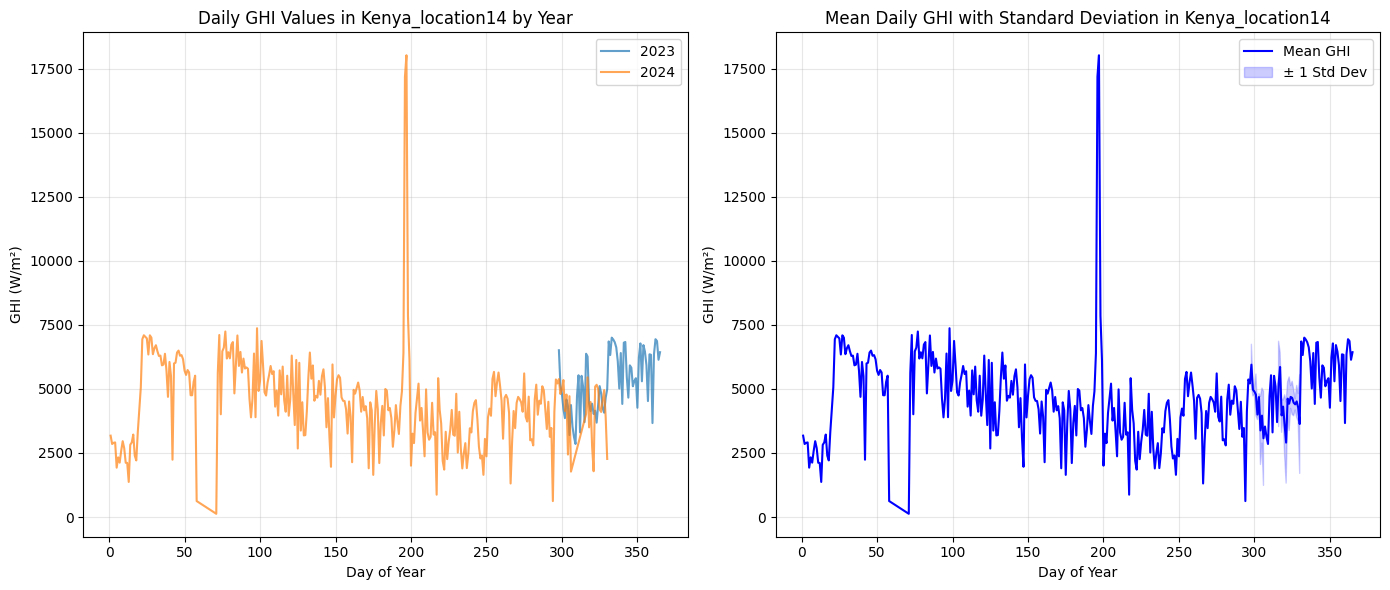

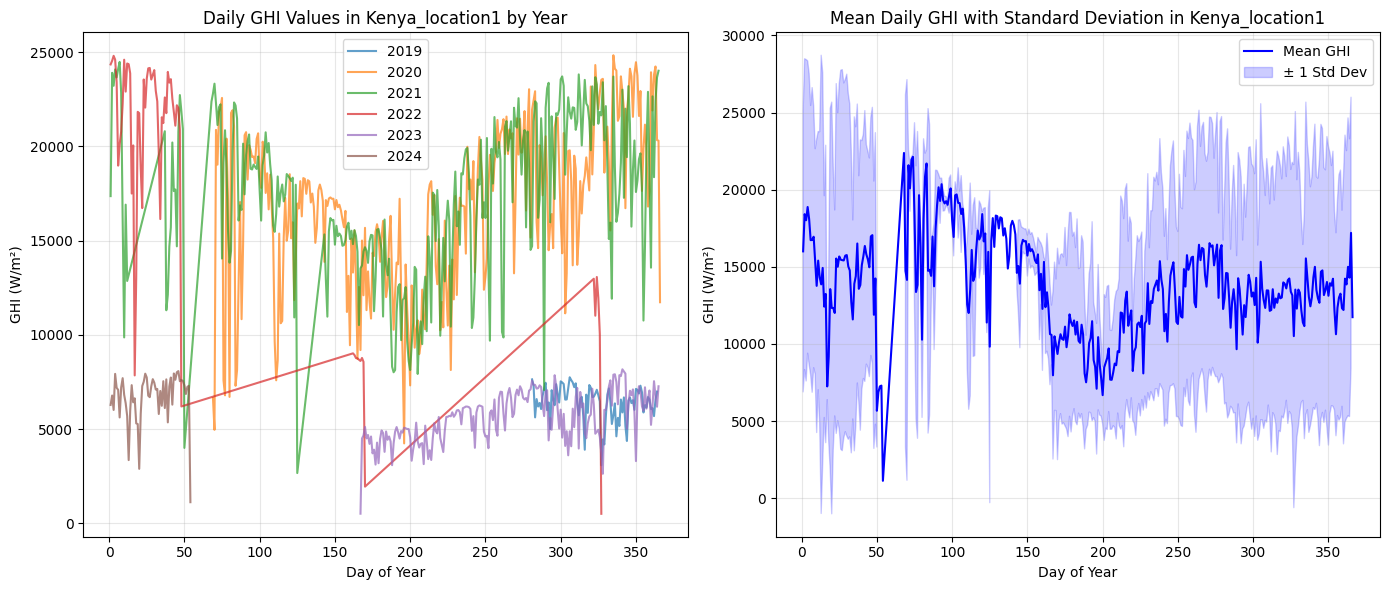

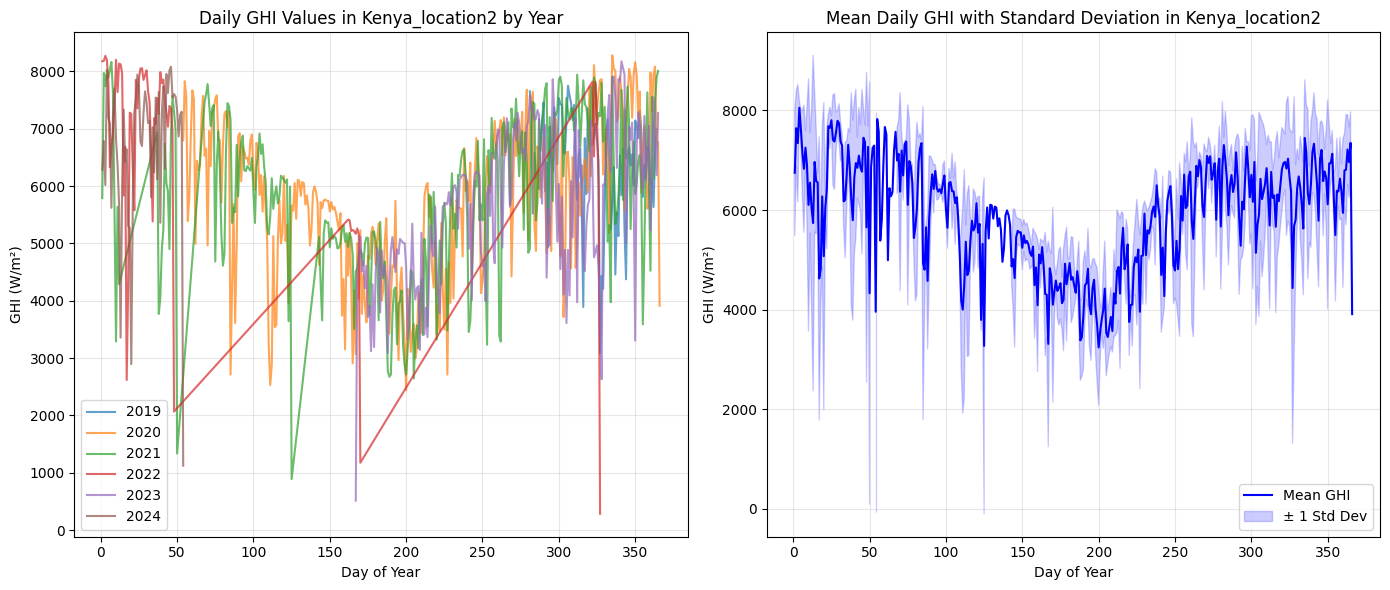

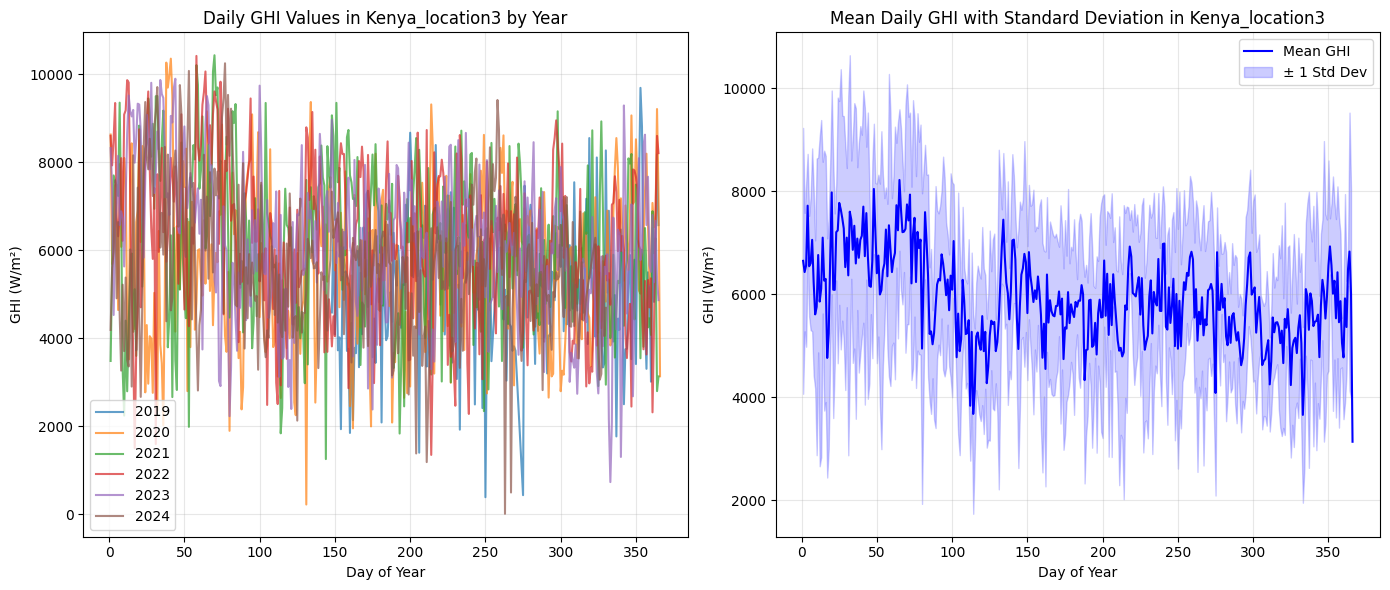

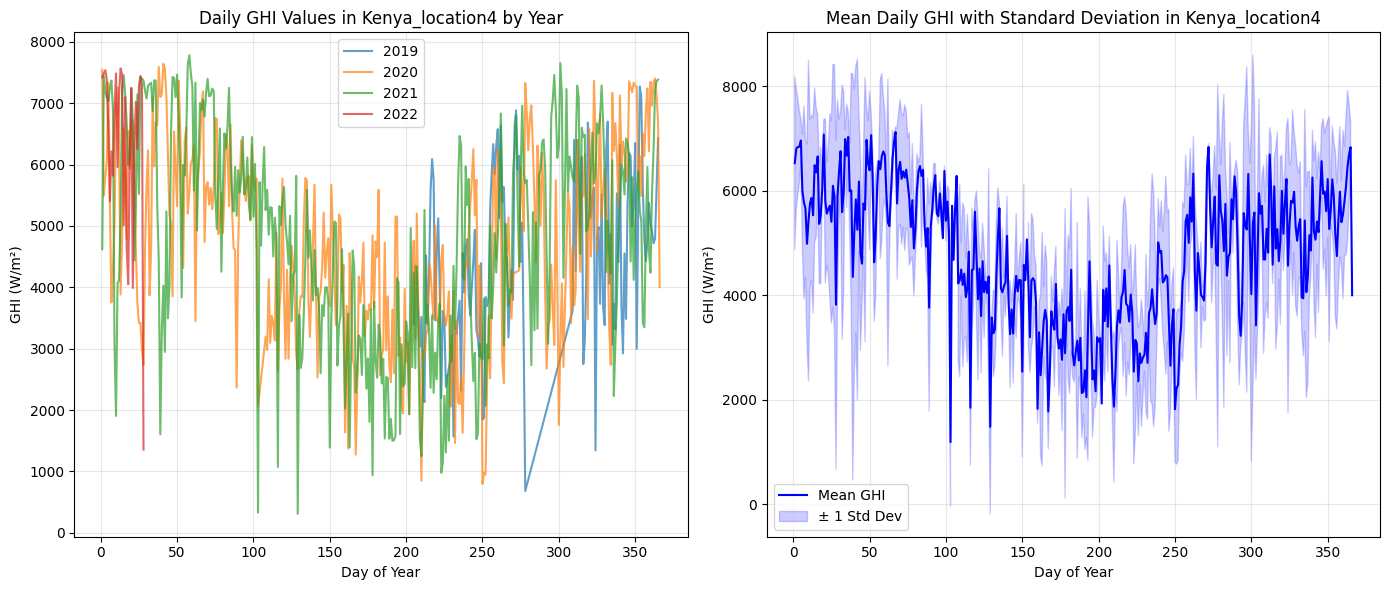

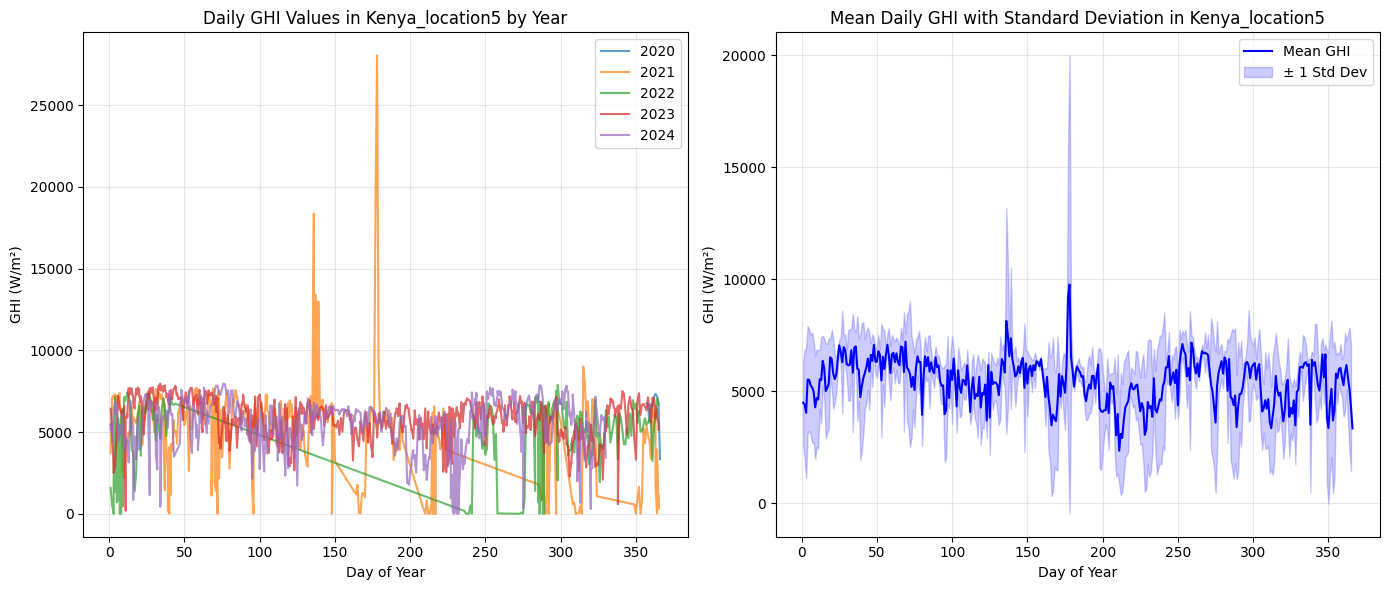

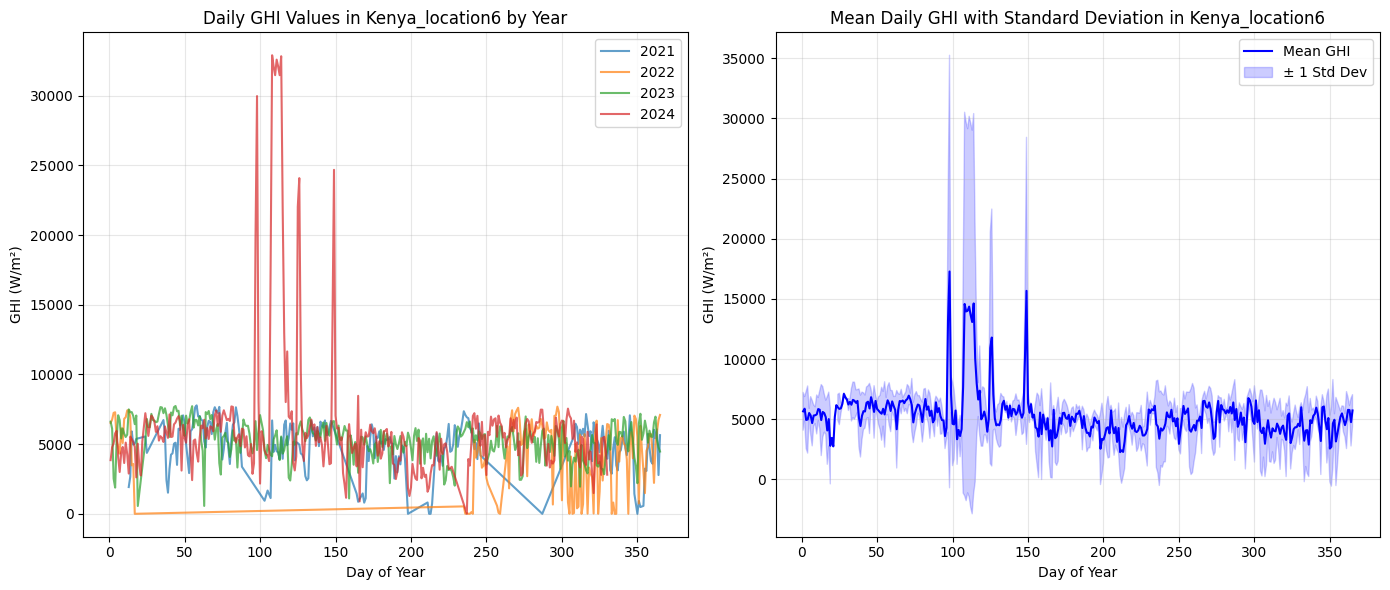

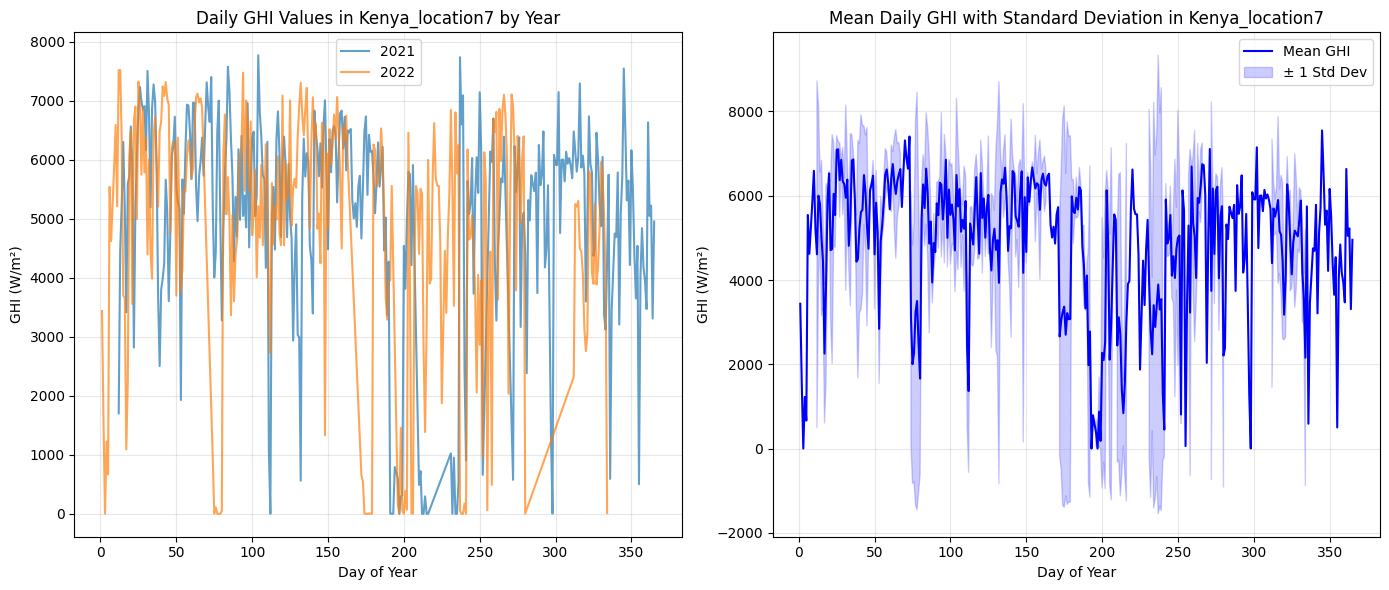

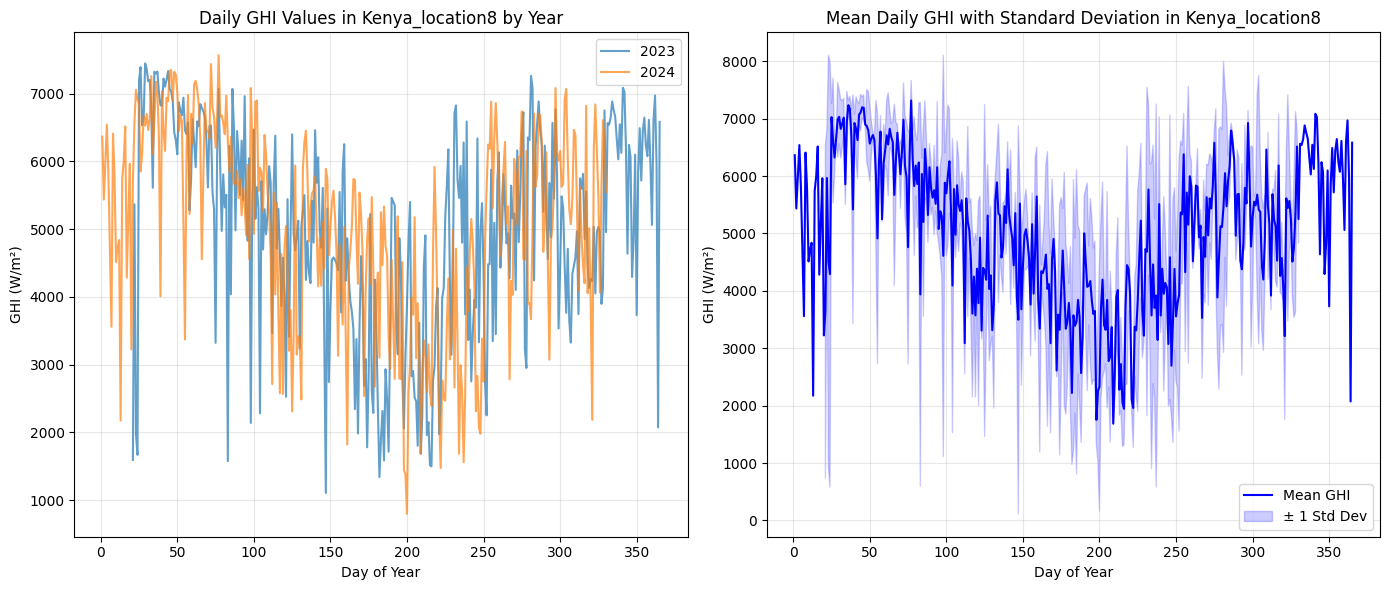

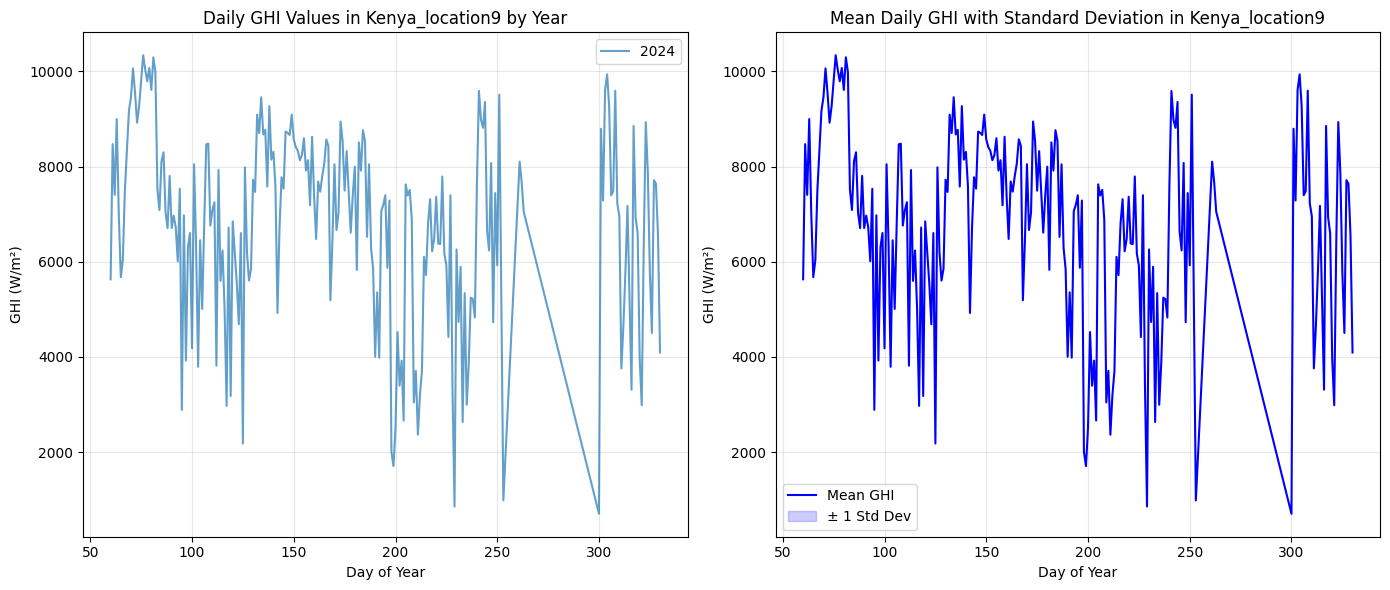

In [34]:
location = 'kenya'
kenya = pd.read_csv(cbe_measurements / f'{location}.csv')
fig, axes = plot_ghi_yearly_distribution(kenya)
plt.show()

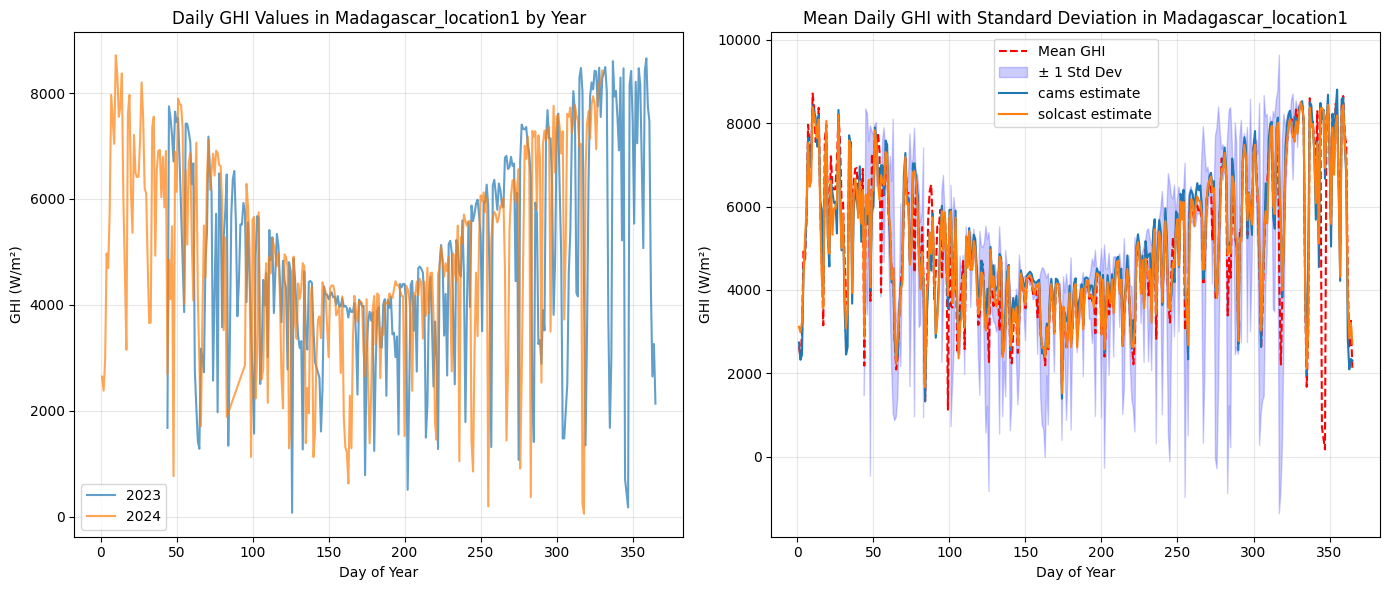

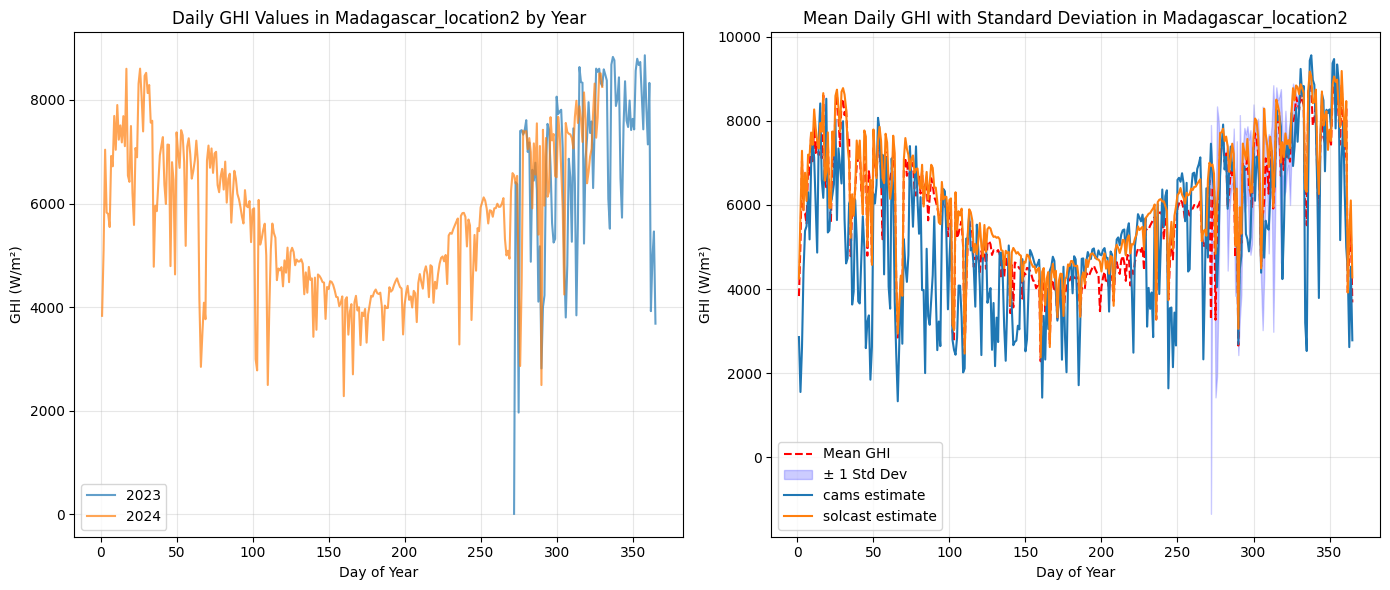

In [28]:
location = 'madagascar'
madagascar = pd.read_csv(cbe_measurements / f'{location}.csv')
madagascar_cams = pd.read_csv(cbe_estimates / f'{location}_cams.csv')
madagascar_solcast = pd.read_csv(cbe_estimates / f'{location}_solcast.csv')
fig, axes = plot_ghi_yearly_distribution(madagascar, [madagascar_cams, madagascar_solcast], ['cams estimate', 'solcast estimate'])
plt.show()

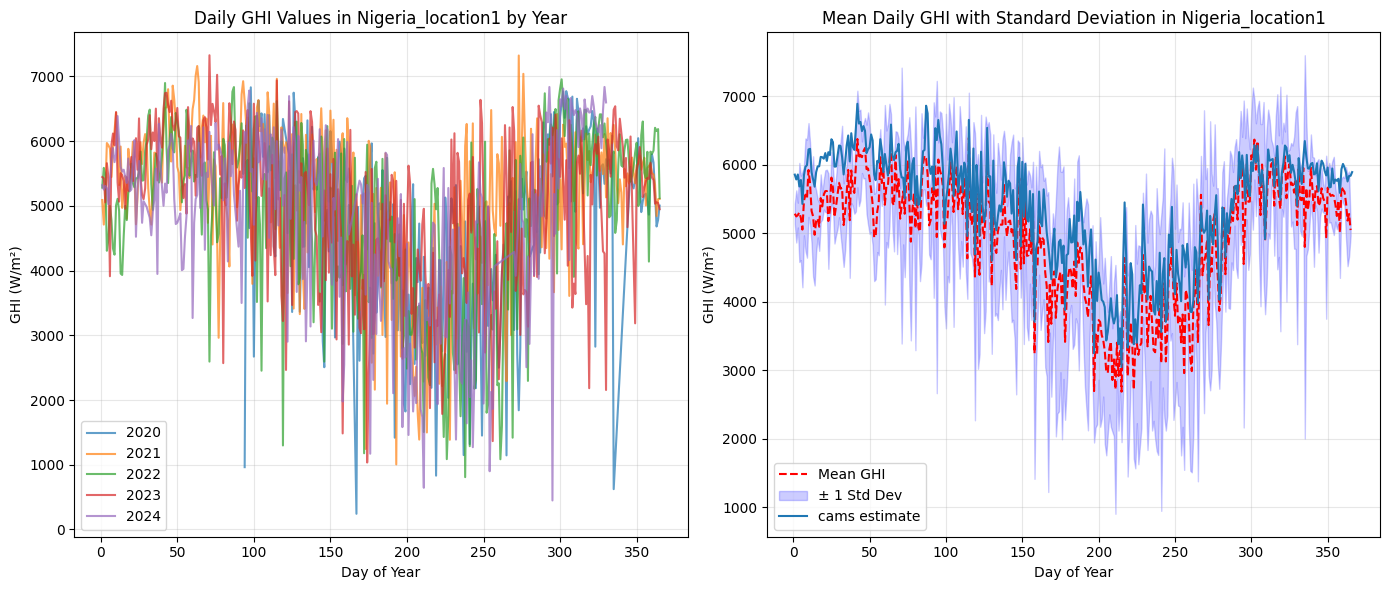

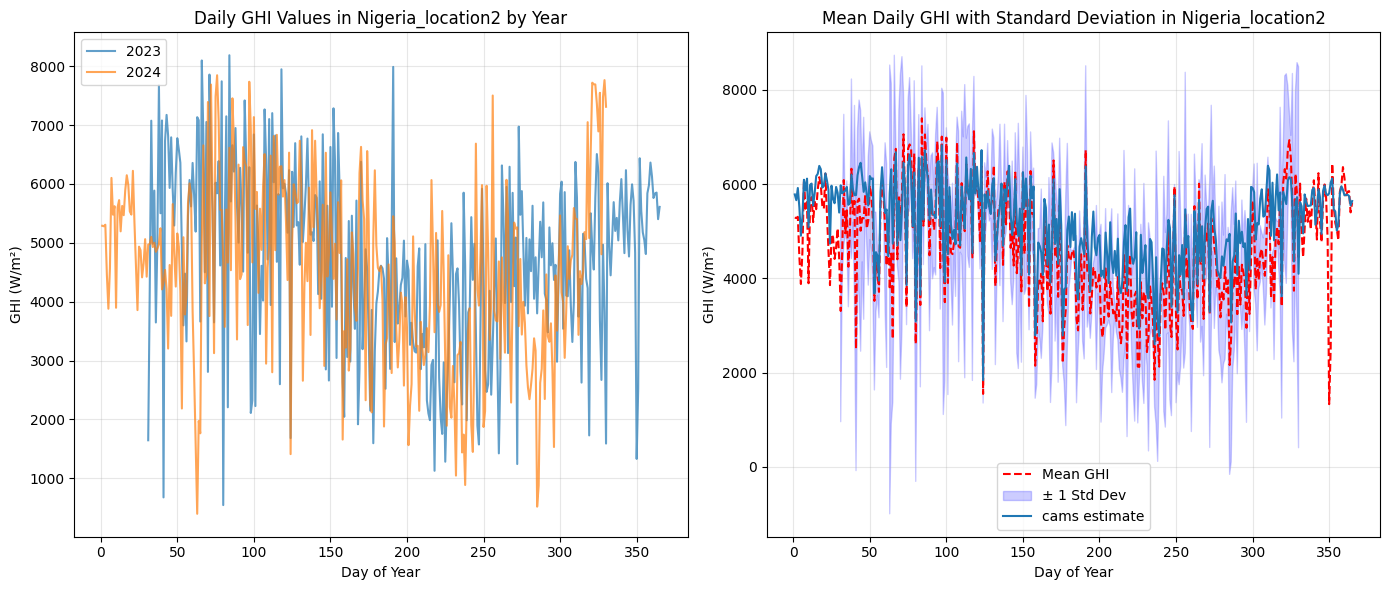

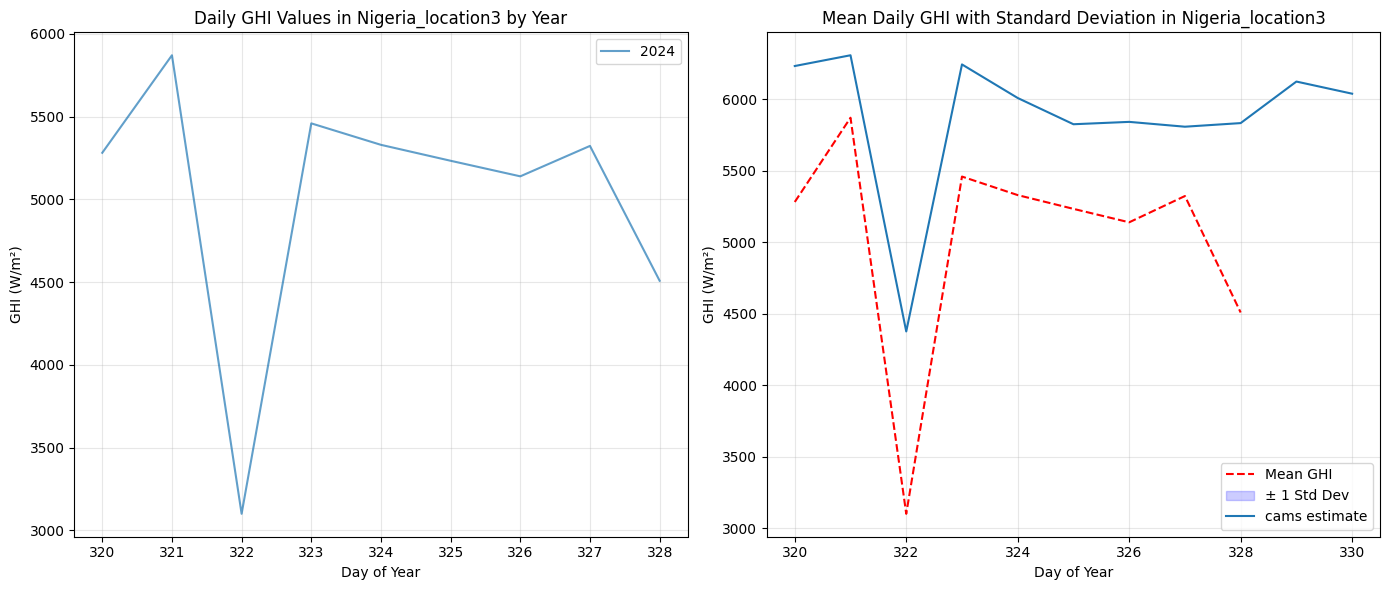

In [30]:
location = 'nigeria'
nigeria = pd.read_csv(cbe_measurements / f'{location}.csv')
nigeria_cams = pd.read_csv(cbe_estimates / f'{location}_cams.csv')
fig, axes = plot_ghi_yearly_distribution(nigeria, [nigeria_cams], ['cams estimate'])
plt.show()  

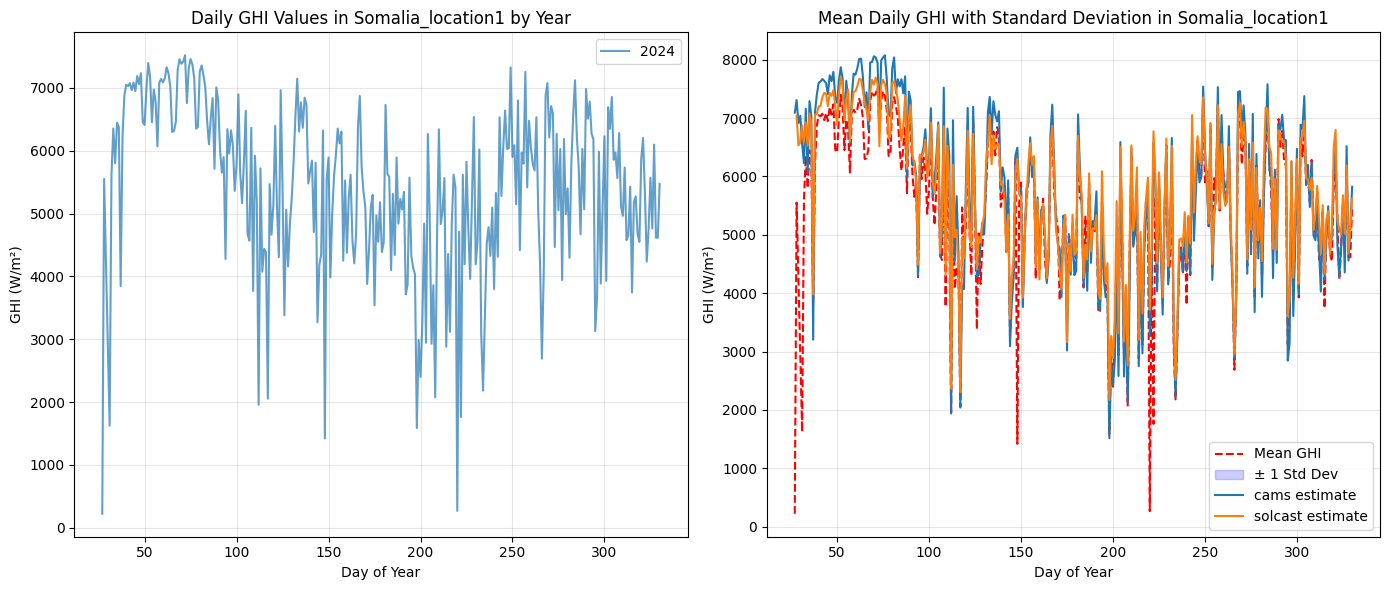

In [31]:
location = 'somalia'
somalia = pd.read_csv(cbe_measurements / f'{location}.csv')
somalia_cams = pd.read_csv(cbe_estimates / f'{location}_cams.csv')
somalia_solcast = pd.read_csv(cbe_estimates / f'{location}_solcast.csv')
fig, axes = plot_ghi_yearly_distribution(somalia, [somalia_cams, somalia_solcast], ['cams estimate', 'solcast estimate'])
plt.show()

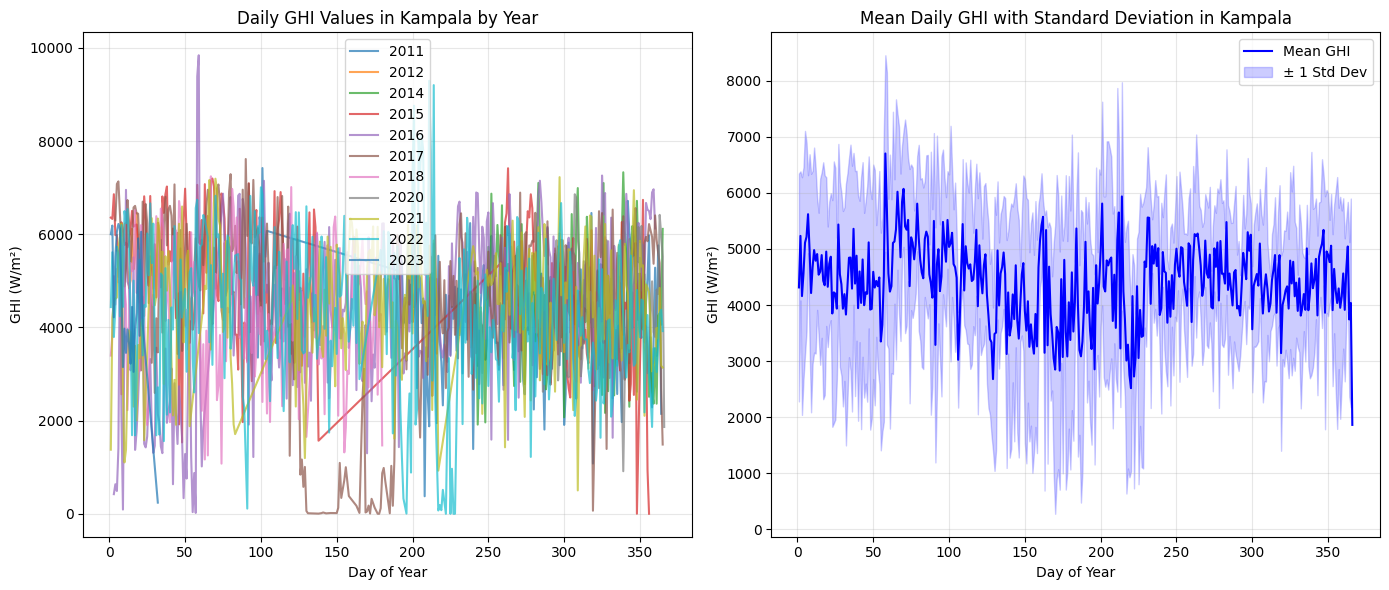

In [14]:
location = 'kampala'
kampala = pd.read_csv(mak_measurements / f'{location}.csv')
fig, axes = plot_ghi_yearly_distribution(kampala)
plt.show()

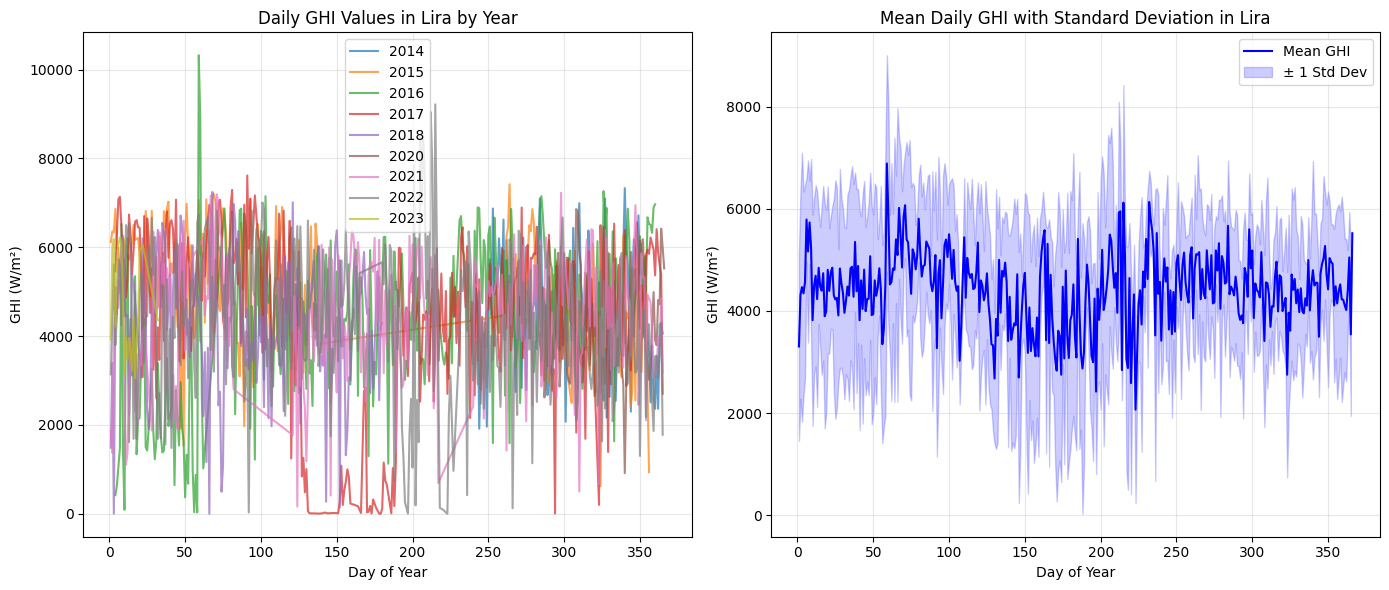

In [15]:
location = 'lira'
lira = pd.read_csv(mak_measurements / f'{location}.csv')
fig, axes = plot_ghi_yearly_distribution(lira)
plt.show()

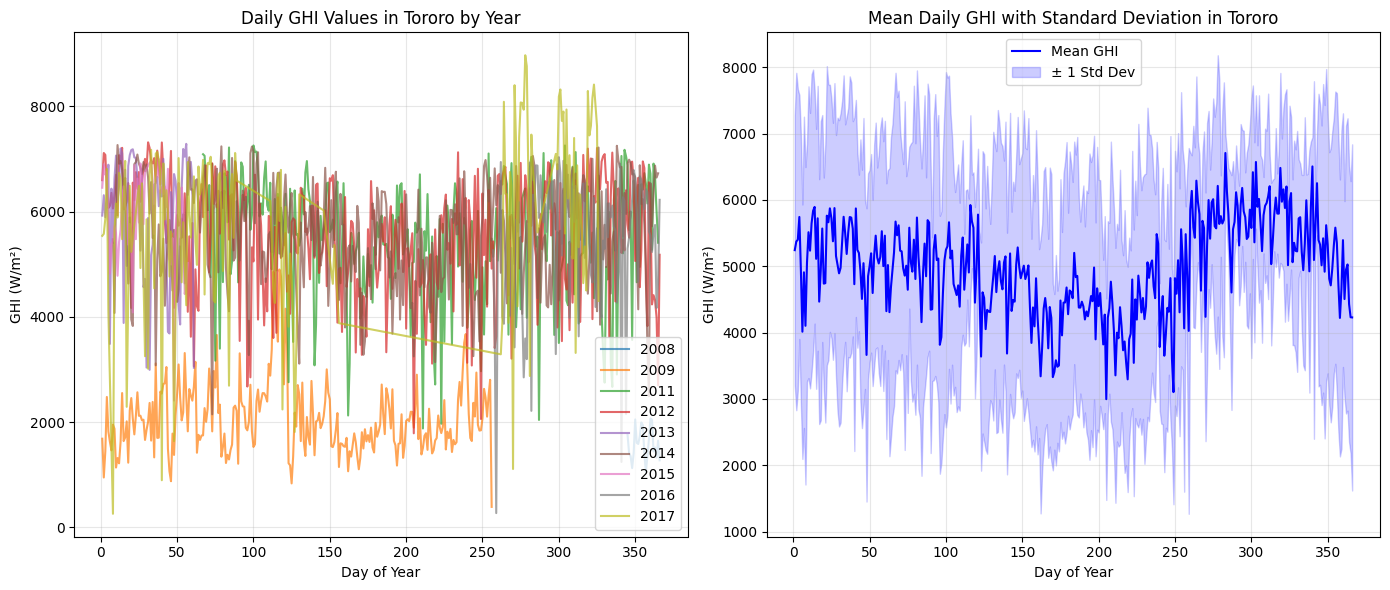

In [16]:
location = 'tororo'
tororo = pd.read_csv(mak_measurements / f'{location}.csv')
fig, axes = plot_ghi_yearly_distribution(tororo)
plt.show()